# STEP 13. 회귀 분석 준비: 군집 테이블과 100 m 상업 버퍼

**목적**: 연구 개요(`SunghoSynn_ResearchOutline.docx`) 다음 단계를 위한 산출물을 만든다. 다음 단계는 각 공원 네트워크·군집의 구성 공원 주변 **100 m 버퍼** 안에서 상업 POI 밀도·다양성·방문량을 재고, 회귀분석을 하는 것이다.

정의(RQ3) 4개마다:
1. **모든 공원에 군집 id 하나**
   - 최종 묶음(도보 10분 지름)에 속하면 그 묶음 id(STEP 11 GeoJSON과 같은 id)
   - 아니면 단독 군집 `{정의}-S-{park_id}`
2. **군집 속성표**
   - 규모: 공원 수, 공원 면적
   - 공간: 범위, 최대 보행거리
   - 구성: 내부 연결 밀도, 쌍별 각도 비용·보행거리
   - **큰길 속성**: NACH 상위 회랑 위 공원 비율, attachment NACH 평균
   - 고립 지수
3. **상업 링 폴리곤**
   - 구성 공원을 각각 100 m 버퍼한 것의 합집합에서 모든 공원 부지를 뺀 영역
   - 다른 군집 링과 겹치는 비율을 기록한다. POI 배정 규칙은 다음 단계에서 정한다.

정의: **D** walking distance · **N1** directional change(γ = 2) · **N2** street-axis continuity · **N3** excess field overlap

출력: `outputs/{AREA}/clusters/` (`park_cluster_membership.csv`, `clusters_{def}.csv`, `clusters_{def}.geojson`, `README.md`)

In [1]:
# ===== 공통 설정 (모든 STEP 노트북에서 동일) =====
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# 분석 지역: "Brooklyn"(파일럿) 또는 "NYC"(전체). 환경변수 PARK_STUDY_AREA로도 지정 가능.
STUDY_AREA = os.environ.get("PARK_STUDY_AREA", "Brooklyn")

ROOT = Path.cwd()
DATA = ROOT / "Data"
PARKS_PATH = DATA / "NYCPark" / "Parks_Properties_20260923.geojson"
NET_DIR = DATA / "derived" / "network"        # STEP1 결과 (지역 무관, NYC+버퍼 전체)
AREA_DIR = DATA / "derived" / STUDY_AREA      # STEP2 이후 결과
OUT_DIR = ROOT / "outputs" / STUDY_AREA
for _d in (NET_DIR, AREA_DIR, OUT_DIR):
    _d.mkdir(parents=True, exist_ok=True)

CRS = 32618            # UTM 18N (m)
R_MAX = 3200           # 탐색 한계 (m) = 보로 네트워크 버퍼 폭
SPEED = 1.0            # speed_m_s=1 -> agg_seconds == 경로 길이(m)

BOROUGHS = {"M": "Manhattan", "X": "Bronx", "B": "Brooklyn", "Q": "Queens", "R": "Staten Island"}
AREA_BOROUGHS = ["B"] if STUDY_AREA == "Brooklyn" else list(BOROUGHS)

# 네트워크 변형: C = 가로 중심선 + 보행전용 경로 (주 분석), S = 보도 포함 전체 보행망 (민감도)
VARIANTS = ["C", "S"]
PRIMARY = "C"
SIDEWALK_FOOTWAYS = {"sidewalk", "crossing", "traffic_island"}

# 공원 필터 (사용자 결정): Flagship + 비공원성 필지 제외, 면적 상한 100 acres (계산은 200 상위집합)
EXCLUDE_TYPES = ["Flagship Park", "Operations", "Lot", "Undeveloped",
                 "Buildings/Institutions", "Cemetery", "Managed Sites"]
AREA_CAP = 100
AREA_CAP_SUPERSET = 200
AREA_CAP_GRID = [50, 100, 200]
RESTRICTED_TYPES = ["Garden", "Jointly Operated Playground"]            # 접근 제한 민감도
STREET_EMBEDDED_TYPES = ["Triangle/Plaza", "Strip", "Mall", "Parkway"]  # 가로 매몰형 민감도

# 공원-네트워크 attachment
ATTACH_BUFFER = {"C": 20.0, "S": 10.0}   # 경계 버퍼 (m): C는 중심선이 도로 폭 절반만큼 떨어져 있음
ATTACH_BUFFER_GRID = {"C": [15.0, 20.0, 30.0], "S": [5.0, 10.0, 20.0]}
INSIDE_SHARE = 0.9       # 공원 내부에 90% 이상 들어간 세그먼트는 attachment에서 제외 (통행은 허용)
K_SOURCES = 8            # 공원당 출발 attachment 최대 개수 (farthest-point sampling)
SMALL_COMPONENT = 200    # 이보다 작은 연결요소에만 붙은 공원은 'unresolved'

# 최종 묶음 공통 절차: 설정별 Louvain(γ) → 보로 단위 퍼콜레이션 필터 → 합의 ≥ 0.5 → 도보 10분 지름 분할
MAIN_GAMMA = 2
COMMERCIAL_BUFFER = 100   # 연구 개요: 군집 구성 공원 주변 100 m = 상업 영역

# 묶음 크기 제약: 묶음 안 모든 공원 쌍이 서로 도보 10분 이내 (보행망 최단거리, 1.33 m/s × 600 s ≈ 800 m)
WALK_LIMIT = 800
WALK_LIMIT_GRID = [400, 800, 1200]   # 5 / 10 / 15분 민감도

# N1 angular few-turn
N1_THETAS = [15, 45, 90, 180]
N1_RADII = [800, 1600, 3200]
N1_REL_Q = [0.1, 0.2]
DIST_BANDS = [0, 200, 400, 800, 1600, 3200]

# D walking distance (근접성 기준선): 보행망 최단거리 ≤ d 이면 연결
D_DISTS = [200, 400, 800]

# N2 street-axis continuity: 같은 연속 가로(stroke) 위, 두 공원 구간 사이 간격 ≤ lim
N2_ALONG = [400, 800, 1600]
# (큰길 속성 계산용) 각도 choice/NACH 반경과 상위 비율
N2_RADII = [800, 1600, 3200]
N2_TOP_P = [0.02, 0.05, 0.10]
STROKE_ANGLE = 30
STROKE_ANGLE_GRID = [20, 30, 45]
N2_MAX_ALONG = [3200, None]

# N3 excess few-turn field overlap
N3_THETAS = [45, 90]
N3_RADII = [800, 1600]
N3_TAU = [0.1, 0.2]
N3_KAPPA = [1.0, 1.25]

print(f"STUDY_AREA={STUDY_AREA}  boroughs={AREA_BOROUGHS}  AREA_DIR={AREA_DIR.relative_to(ROOT)}")

STUDY_AREA=NYC  boroughs=['M', 'X', 'B', 'Q', 'R']  AREA_DIR=Data/derived/NYC


In [2]:
from scipy.spatial.distance import pdist
from shapely.geometry import box
import matplotlib.pyplot as plt

GJ = OUT_DIR / "geojson"
CL_DIR = OUT_DIR / "clusters"
CL_DIR.mkdir(parents=True, exist_ok=True)
DEFS = {  # 정의: (공원 레이어, 묶음 id 열, 연결선 레이어)
    "D": ("parks_D_walking_distance", "group_id", "edges_D"),
    "N1": ("parks_N1_angular_fewturn", "group_g2", "edges_N1"),
    "N2": ("parks_N2_street_axis", "group_id", "edges_N2"),
    "N3": ("parks_N3_field_overlap", "group_id", "edges_N3"),
}
parks = gpd.read_parquet(NET_DIR / "parks.parquet")
LAY = {d: gpd.read_file(GJ / f"{f}.geojson").set_index("park_id", drop=False) for d, (f, _, _) in DEFS.items()}
PIDS = LAY["N1"].index.tolist()
geom = parks.loc[PIDS].geometry
PT = geom.representative_point()
print(f"{STUDY_AREA}: {len(PIDS):,} park features")

# 공원 쌍 보행거리·각도 비용
pp = pd.read_parquet(AREA_DIR / f"pairs_{PRIMARY}.parquet", columns=["cfg", "i", "j", "D_net", "A_1600"])
pp = pp[pp.cfg == f"d{int(ATTACH_BUFFER[PRIMARY])}_K{K_SOURCES}"]
PAIR = pp.assign(a=np.minimum(pp.i, pp.j), b=np.maximum(pp.i, pp.j)).groupby(["a", "b"])[["D_net", "A_1600"]].min()
DNET, ANG = PAIR.D_net.dropna().to_dict(), PAIR.A_1600.dropna().to_dict()
key = lambda a, b: (a, b) if a < b else (b, a)

NYC: 2,057 park features


## 13-1. 공원 단위 큰길 속성
- `on_main_5`, `on_main_10`: 공원 attachment가 NACH-1600 상위 5%·10% 회랑 stroke(각도 연속 30°)에 붙어 있는지. STEP 5에서 계산한 값이다.
- `nach_1600_mean`: 공원 attachment 세그먼트의 NACH-1600 평균. 연속값이다.

In [3]:
corr = pd.read_parquet(AREA_DIR / f"corridors_{PRIMARY}.parquet")
ps = pd.read_parquet(AREA_DIR / f"park_stroke_{PRIMARY}.parquet")
ps = ps[ps.angle == STROKE_ANGLE]
PARKATTR = pd.DataFrame(index=pd.Index(PIDS, name="park_id"))
for p_ in [0.05, 0.10]:
    sel = set(corr[(corr.angle == STROKE_ANGLE) & (corr.r == 1600) & (corr.p == p_)].stroke)
    on = ps[ps.stroke.isin(sel)].park_id.unique()
    PARKATTR[f"on_main_{int(p_ * 100)}"] = PARKATTR.index.isin(on)
cent = pd.read_parquet(AREA_DIR / f"centrality_{PRIMARY}.parquet", columns=["nach_1600"])
att = pd.read_parquet(NET_DIR / "attachments.parquet")
att = att[(att.variant == PRIMARY) & att.is_default]
PARKATTR["nach_1600_mean"] = att.join(cent, on="seg_id").groupby("park_id").nach_1600.mean().reindex(PIDS)
PARKATTR.describe(include="all").round(3)

,on_main_5,on_main_10,nach_1600_mean
count,2057,2057,2047.000
unique,2,2,NaN
top,False,False,NaN
freq,1608,1196,NaN
mean,NaN,NaN,0.977
std,NaN,NaN,0.202
min,NaN,NaN,0.000
25%,NaN,NaN,0.907
50%,NaN,NaN,1.019
75%,NaN,NaN,1.111


## 13-2. 모든 공원 → 군집 id (단독 포함)

In [4]:
memb = pd.DataFrame(index=pd.Index(PIDS, name="park_id"))
memb["name"] = parks.loc[PIDS, "name"]
memb["parent_id"] = parks.loc[PIDS, "parent_id"]
for d, (_, col, _) in DEFS.items():
    gid = LAY[d][col].reindex(PIDS)
    memb[f"{d}_cluster"] = gid.where(gid.notna(), [f"{d}-S-{p_}" for p_ in PIDS])
    memb[f"{d}_in_group"] = gid.notna()
    memb[f"{d}_status"] = LAY[d]["status"].reindex(PIDS)
memb.to_csv(CL_DIR / "park_cluster_membership.csv")
pd.DataFrame({d: {"multi-park clusters": memb.loc[memb[f"{d}_in_group"], f"{d}_cluster"].nunique(),
                  "parks in multi-park clusters": int(memb[f"{d}_in_group"].sum()),
                  "singleton clusters": int((~memb[f"{d}_in_group"]).sum()),
                  "total clusters": memb[f"{d}_cluster"].nunique()} for d in DEFS})

,D,N1,N2,N3
multi-park clusters,349,340,329,47
parks in multi-park clusters,1274,1178,1212,113
singleton clusters,783,879,845,1944
total clusters,1132,1219,1174,1991


## 13-3. 상업 링 (100 m 버퍼 − 공원 부지)
공원 부지는 **NYC Parks 전체 폴리곤**(Flagship·대형 공원 포함)을 뺀다. 공원 안은 상업 지역이 아니기 때문이다.

In [5]:
all_parks = gpd.read_file(PARKS_PATH).to_crs(CRS)
all_parks_union = all_parks.geometry.make_valid().union_all()
park_buf = geom.buffer(COMMERCIAL_BUFFER)


def cluster_ring(members):
    return park_buf.loc[members].union_all().difference(all_parks_union)

## 13-4. 군집 속성표 + 링 레이어

In [6]:
def cluster_table(d):
    _, col, efile = DEFS[d]
    e = gpd.read_file(GJ / f"{efile}.geojson", ignore_geometry=True)
    robust = set(zip(e.loc[e.share >= 0.5, "park_i"], e.loc[e.share >= 0.5, "park_j"]))
    lay = LAY[d]
    rows = []
    for cid, members in memb.groupby(f"{d}_cluster").groups.items():
        m = sorted(members)
        n = len(m)
        pairs = [(a, b) for k, a in enumerate(m) for b in m[k + 1:]]
        walks = [DNET.get(key(a, b), np.inf) for a, b in pairs]
        angs = [ANG.get(key(a, b), np.nan) for a, b in pairs]
        n_int = sum(key(a, b) in robust for a, b in pairs)
        types = parks.loc[m, "typecategory"]
        rows.append({
            "definition": d, "cluster_id": cid, "n_parks": n, "is_singleton": n == 1,
            "park_ids": ";".join(m), "park_names": "; ".join(parks.loc[m, "name"].astype(str)),
            "boroughs": "/".join(sorted(parks.loc[m, "borough"].unique())),
            "park_area_acres": round(float(parks.loc[m, "piece_acres"].sum()), 3),
            "dominant_type": types.mode().iloc[0], "n_types": types.nunique(),
            "extent_km": round(pdist(np.c_[PT[m].x, PT[m].y]).max() / 1000, 3) if n > 1 else 0.0,
            "max_walk_m": round(max(walks), 1) if n > 1 else 0.0,
            "median_walk_m": round(float(np.median(walks)), 1) if n > 1 else np.nan,
            "internal_robust_links": n_int,
            "link_density": round(n_int / len(pairs), 3) if n > 1 else np.nan,
            "median_angle_deg": round(float(np.nanmedian(angs)), 1) if n > 1 and np.isfinite(angs).any() else np.nan,
            "share_on_main_5": round(float(PARKATTR.loc[m, "on_main_5"].mean()), 3),
            "share_on_main_10": round(float(PARKATTR.loc[m, "on_main_10"].mean()), 3),
            "nach_1600_mean": round(float(PARKATTR.loc[m, "nach_1600_mean"].mean()), 4),
            "isolation_persistence_mean": round(float(lay.loc[m, "isolation_persistence"].mean()), 3),
            "geometry": cluster_ring(m),
        })
    t = gpd.GeoDataFrame(rows, geometry="geometry", crs=CRS)
    t["ring_area_m2"] = t.area.round(1)
    # 같은 정의 안에서 다른 군집 링과 겹치는 비율
    sidx = t.sindex
    ov = []
    for k, g in enumerate(t.geometry):
        cand = [c for c in sidx.query(g, predicate="intersects") if c != k]
        ov.append(g.intersection(t.geometry.iloc[cand].union_all()).area / g.area if cand and g.area > 0 else 0.0)
    t["overlap_other_clusters_share"] = np.round(ov, 3)
    return t


TABLES = {}
for d in DEFS:
    t = cluster_table(d)
    TABLES[d] = t
    t.drop(columns="geometry").to_csv(CL_DIR / f"clusters_{d}.csv", index=False)
    t.to_crs(4326).to_file(CL_DIR / f"clusters_{d}.geojson", driver="GeoJSON")
    print(d, len(t), "clusters")
summary = pd.DataFrame({d: {
    "clusters": len(t), "multi-park": int((~t.is_singleton).sum()), "singletons": int(t.is_singleton.sum()),
    "median parks (multi)": t.loc[~t.is_singleton, "n_parks"].median(),
    "median max walk m (multi)": t.loc[~t.is_singleton, "max_walk_m"].median(),
    "median ring area ha": round(t.ring_area_m2.median() / 1e4, 2),
    "mean overlap share": round(t.overlap_other_clusters_share.mean(), 3),
    "multi-park clusters touching a top-5% main street": round(float((t.loc[~t.is_singleton, "share_on_main_5"] > 0).mean()), 3),
} for d, t in TABLES.items()})
summary.to_csv(CL_DIR / "cluster_summary.csv")
summary

D 1132 clusters


N1 1219 clusters


N2 1174 clusters


N3 1991 clusters


,D,N1,N2,N3
clusters,1132.000,1219.000,1174.000,1991.000
multi-park,349.000,340.000,329.000,47.000
singletons,783.000,879.000,845.000,1944.000
median parks (multi),3.000,3.000,3.000,2.000
median max walk m (multi),197.700,391.400,336.300,413.600
median ring area ha,7.490,7.510,7.440,5.630
mean overlap share,0.104,0.241,0.211,0.367
multi-park clusters touching a top-5% main street,0.450,0.468,0.465,0.085


## 13-5. 검증

In [7]:
for d, t in TABLES.items():
    ids = [p_ for s_ in t.park_ids for p_ in s_.split(";")]
    assert len(ids) == len(set(ids)) == len(PIDS), d                      # 공원-군집 1:1
    assert t.geometry.is_valid.all(), d
    assert (t.loc[~t.is_singleton, "max_walk_m"] <= WALK_LIMIT + 1e-6).all(), d
    n_groups = LAY[d][DEFS[d][1]].dropna().nunique()
    assert (~t.is_singleton).sum() == n_groups, d                        # 군집 수 = 묶음 수 + 단독 수
print("✓ every park is in exactly one cluster per definition; rings valid; walking diameter ≤ 800 m")
empty = {d: int(t.geometry.is_empty.sum()) for d, t in TABLES.items()}
print("empty rings (park fully surrounded by park land):", empty)

✓ every park is in exactly one cluster per definition; rings valid; walking diameter ≤ 800 m
empty rings (park fully surrounded by park land): {'D': 0, 'N1': 0, 'N2': 0, 'N3': 0}


## 13-6. 미리보기: 같은 지역의 정의별 군집 상업 링

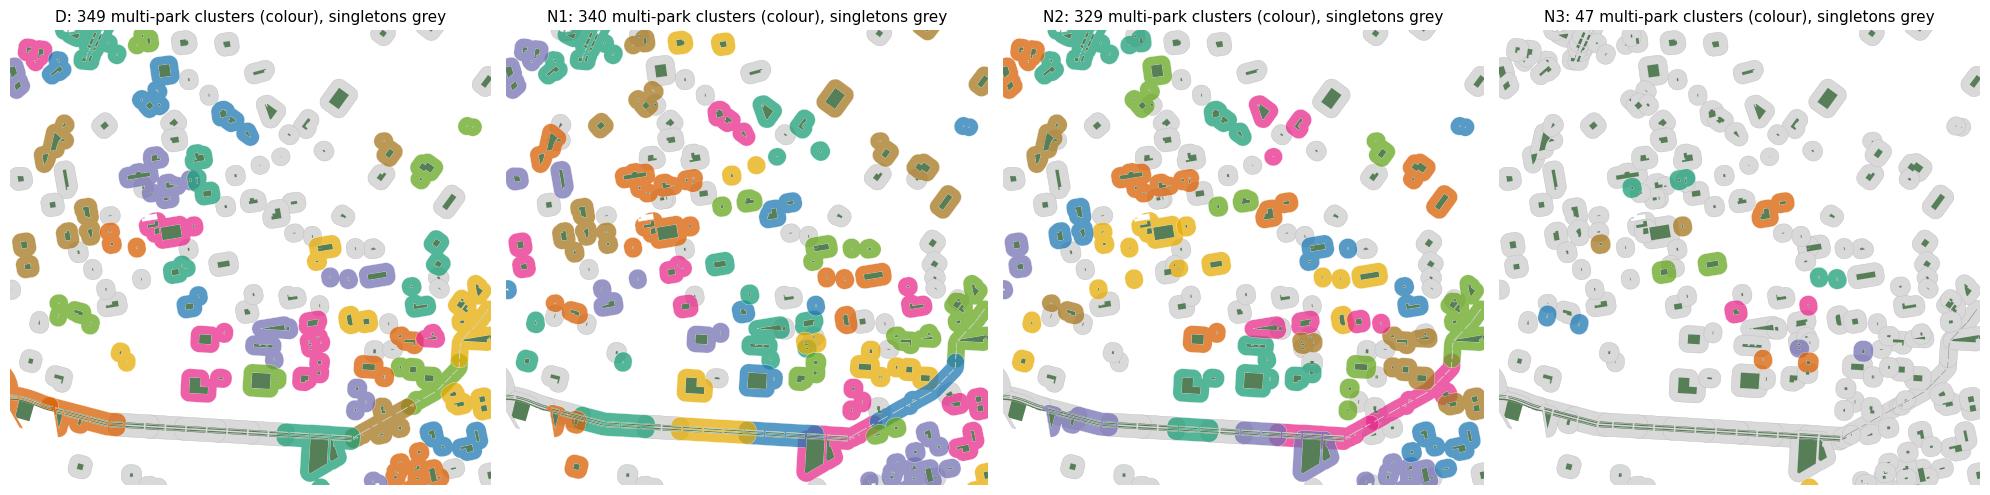

In [8]:
win = gpd.GeoSeries([box(-73.968, 40.664, -73.904, 40.710)], crs=4326).to_crs(CRS).iloc[0]
pal = ["#1B9E77", "#D95F02", "#7570B3", "#E7298A", "#66A61E", "#E6AB02", "#A6761D", "#1F78B4"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5.6))
for ax, (d, t) in zip(axes, TABLES.items()):
    sub = t[t.intersects(win)]
    multi = sub[~sub.is_singleton]
    sub[sub.is_singleton].plot(ax=ax, color="#D9D9D9", edgecolor="#BDBDBD", lw=0.3)
    multi.plot(ax=ax, color=[pal[k % len(pal)] for k in range(len(multi))], alpha=0.75, edgecolor="white", lw=0.3)
    parks.loc[PIDS][parks.loc[PIDS].intersects(win)].plot(ax=ax, color="#2C5F2D", alpha=0.8)
    ax.set_xlim(win.bounds[0], win.bounds[2]); ax.set_ylim(win.bounds[1], win.bounds[3]); ax.set_axis_off()
    ax.set_title(f"{d}: {int((~t.is_singleton).sum())} multi-park clusters (colour), singletons grey", fontsize=11)
plt.tight_layout()
fig.savefig(CL_DIR / "preview_rings_B.png", dpi=160)
plt.show()

## 13-7. 데이터 사전 (README.md)

In [9]:
readme = f"""# Park clusters and 100 m commercial rings ({STUDY_AREA})

Generated by `14_step13_cluster_table.ipynb` for the next stage of the research outline (commercial activity around park networks).

## Definitions (RQ3)
| key | network definition |
|---|---|
| D | walking distance: shortest walking distance ≤ d (d ∈ {{200, 400, 800}} m) — proximity baseline |
| N1 | directional change: simplest route between the parks turns ≤ θ (few turns), Louvain γ = 2 |
| N2 | street-axis continuity: both parks on the same continuous street axis (angular-continuity stroke) |
| N3 | excess few-turn field overlap |

All multi-park clusters satisfy: every pair of parks within a 10-minute walk ({WALK_LIMIT} m). Parks not in a robust group are **singleton clusters** (`<def>-S-<park_id>`), so every park belongs to exactly one cluster per definition.

## Files
- `park_cluster_membership.csv` — one row per park feature: cluster id, in_group flag and status for each definition
- `clusters_<def>.csv` — one row per cluster (attributes below)
- `clusters_<def>.geojson` — same rows; geometry = **commercial ring**: union of {COMMERCIAL_BUFFER} m buffers around member parks minus all NYC park land (EPSG:4326)
- `cluster_summary.csv`, `preview_rings_B.png`

## Cluster fields
| field | meaning |
|---|---|
| n_parks, is_singleton, park_ids, park_names, boroughs | membership |
| park_area_acres | park supply inside the cluster (sum of member feature areas) |
| dominant_type, n_types | NYC Parks typecategory mix |
| extent_km | largest straight-line distance between member parks |
| max_walk_m, median_walk_m | largest / median shortest walking distance between member parks (max ≤ 800 m) |
| internal_robust_links, link_density | member pairs linked in ≥ 50% of the definition's settings, and share of all member pairs |
| median_angle_deg | median minimum angular cost (simplest path ≤ 1.6 km) between member parks |
| share_on_main_5 / share_on_main_10 | share of member parks attached to a top-5% / top-10% NACH-1600 street axis (“main street” attribute) |
| nach_1600_mean | mean NACH-1600 of member parks' attachment segments |
| isolation_persistence_mean | mean share of settings in which members have no link |
| ring_area_m2 | commercial ring area |
| overlap_other_clusters_share | share of the ring overlapping rings of other clusters of the same definition (POI assignment rule to be decided) |
"""
(CL_DIR / "README.md").write_text(readme)
print(sorted(p_.name for p_ in CL_DIR.iterdir()))

['README.md', 'cluster_summary.csv', 'clusters_D.csv', 'clusters_D.geojson', 'clusters_N1.csv', 'clusters_N1.geojson', 'clusters_N2.csv', 'clusters_N2.geojson', 'clusters_N3.csv', 'clusters_N3.geojson', 'park_cluster_membership.csv', 'preview_rings_B.png']
